In [1]:
!pip install yfinance

  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 18.7 MB/s  0:00:00
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)

   -------- ------------------------------- 1/5 [websockets]
   -------- ------------------------------- 1/5 [websockets]
   ---------------- ----------------------- 2/5 [peewee]
   ---------------- ----------------------- 2/5 [peewee]
   ---------------- ----------------------- 2/5 [peewee]
   ---------------- ----------------------- 2/5 [peewee]
   ------------------------ --------------- 3/5 [curl_cffi]
   ------------------------ --------------- 3/5 [curl_cffi]
   -------------------------------- ------- 4/5 [yfinance]
   -------------------------------- ------- 4/5 [yfinance]
   ---------------------------------------- 5/5 [yfinance]



In [2]:
import seaborn as sns
import yfinance as yf
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# history of all crypto--

In [3]:
btc=yf.Ticker('BTC-USD')
prices1=btc.history(period='5y')
prices1.drop(columns=['Open','High','Low','Dividends','Stock Splits'],axis=1,inplace=True)

In [4]:
eth = yf.Ticker('ETH-USD')
prices2 = eth.history(period='5y')
prices2.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)


In [5]:
usdt = yf.Ticker('USDT-USD')
prices3 = usdt.history(period='5y')
prices3.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)


In [7]:
bnb=yf.Ticker('BNB-USD')
prices4=bnb.history(period='5y')
prices4.drop(columns=['Open','High','Low','Dividends','Stock Splits'],axis=1,inplace=True)

In [8]:
p1 = prices1.join(prices2, lsuffix = ' (BTC)', rsuffix = ' (ETH)')
p2 = prices3.join(prices4, lsuffix = ' (USDT)', rsuffix = ' (BNB)')
data = p1.join(p2, lsuffix = '_', rsuffix = '_')

# create the dataframe

In [9]:
data.head()

,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,,
2021-10-09 00:00:00+00:00,54968.222656,32491211414,3575.716797,12707036942,1.000046,67391135102,421.549469,1404867667
2021-10-10 00:00:00+00:00,54771.578125,39527792364,3425.852783,16171746693,1.001018,69927661418,405.069305,1437068558
2021-10-11 00:00:00+00:00,57484.789062,42637331698,3545.354004,18579189588,1.000696,75741431317,413.456207,1473121389
2021-10-12 00:00:00+00:00,56041.058594,41083758949,3492.573242,18109578443,1.000096,73275476508,443.867523,3142304145
2021-10-13 00:00:00+00:00,57401.097656,41684252783,3606.201660,16211275589,1.000097,78117249743,470.749695,5149146903


In [10]:
data.tail()

,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,,
2026-10-04 00:00:00+00:00,86480.304688,15031650242,2726.509033,5943841130,0.999790,38186771396,795.264099,1195825218
2026-10-05 00:00:00+00:00,85786.593750,30242651384,2711.031494,12303844539,0.999853,71514114557,786.810486,1629945521
2026-10-06 00:00:00+00:00,85557.562500,25245965925,2697.516357,10986122667,0.999845,60953147088,779.615967,1273219160
2026-10-07 00:00:00+00:00,83275.929688,38737709051,2573.527344,20082324906,0.999445,88736239765,772.301270,1545007708
2026-10-09 00:00:00+00:00,82292.570312,43922284544,2489.320068,19351347200,0.999200,94872002560,740.679993,1955062016


In [11]:
data.shape

(1826, 8)

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1826 entries, 2021-10-09 00:00:00+00:00 to 2026-10-09 00:00:00+00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Close (BTC)    1826 non-null   float64
 1   Volume (BTC)   1826 non-null   int64  
 2   Close (ETH)    1826 non-null   float64
 3   Volume (ETH)   1826 non-null   int64  
 4   Close (USDT)   1826 non-null   float64
 5   Volume (USDT)  1826 non-null   int64  
 6   Close (BNB)    1826 non-null   float64
 7   Volume (BNB)   1826 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 128.4 KB


In [13]:
data.isna().sum()

Close (BTC)      0
Volume (BTC)     0
Close (ETH)      0
Volume (ETH)     0
Close (USDT)     0
Volume (USDT)    0
Close (BNB)      0
Volume (BNB)     0
dtype: int64

In [14]:
data.describe()

,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
count,1826.000000,1.826000e+03,1826.000000,1.826000e+03,1826.000000,1.826000e+03,1826.000000,1.826000e+03
mean,58834.475571,3.468169e+10,2511.953862,1.760245e+10,0.999977,6.772090e+10,509.531174,1.631127e+09
std,29834.897131,2.057604e+10,881.602458,1.183600e+10,0.000659,4.223583e+10,219.162998,1.091476e+09
min,15787.284180,5.331173e+09,993.636780,2.081626e+09,0.995872,9.989859e+09,197.042999,2.038465e+08
25%,29410.323730,2.040077e+10,1810.140747,9.459928e+09,0.999679,3.931884e+10,304.741547,9.021106e+08
50%,60824.142578,3.019101e+10,2371.458374,1.503014e+10,1.000062,5.808910e+10,553.516235,1.521219e+09
75%,82254.160156,4.263211e+10,3133.937500,2.173442e+10,1.000285,8.340618e+10,638.678894,2.018161e+09
max,124752.531250,1.817464e+11,4831.348633,9.773662e+10,1.007690,3.443980e+11,1310.214355,1.182039e+10


# Exploratory data analysis

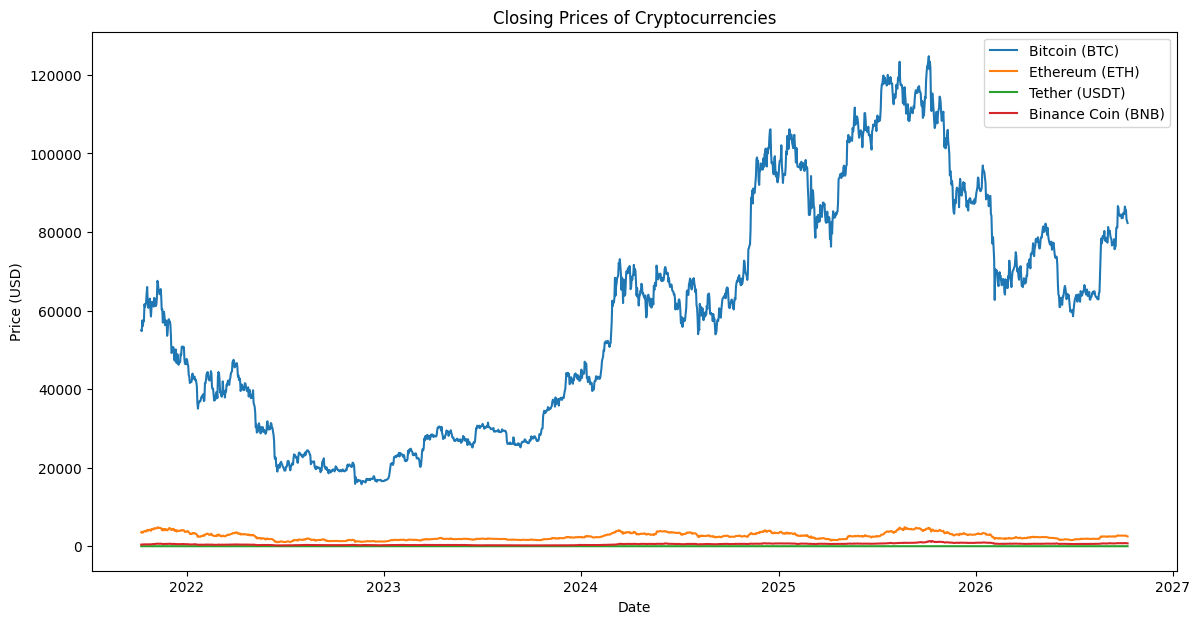

In [15]:
plt.figure(figsize=(14,7))
plt.plot(data.index, data['Close (BTC)'], label='Bitcoin (BTC)')
plt.plot(data.index, data['Close (ETH)'], label='Ethereum (ETH)')
plt.plot(data.index, data['Close (USDT)'], label='Tether (USDT)')
plt.plot(data.index, data['Close (BNB)'], label='Binance Coin (BNB)')
plt.title('Closing Prices of Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

<Axes: xlabel='Date'>

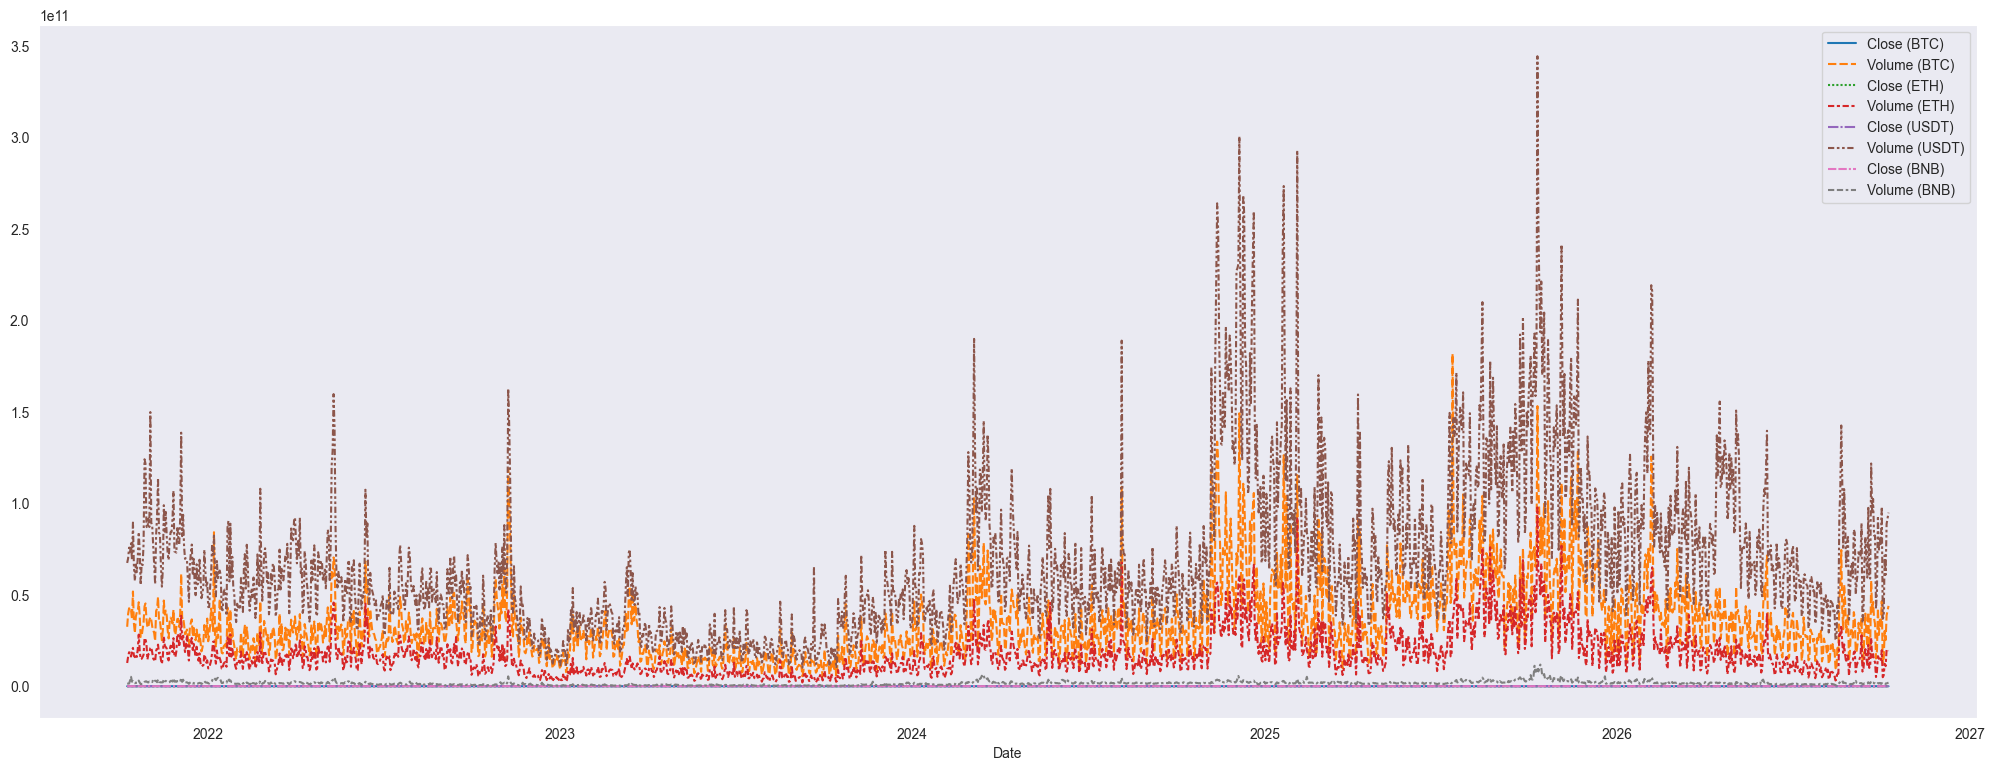

In [21]:
plt.figure(figsize =(25,9))
sns.set_style('dark')
sns.lineplot(data=data)

# visualize the trading volumes

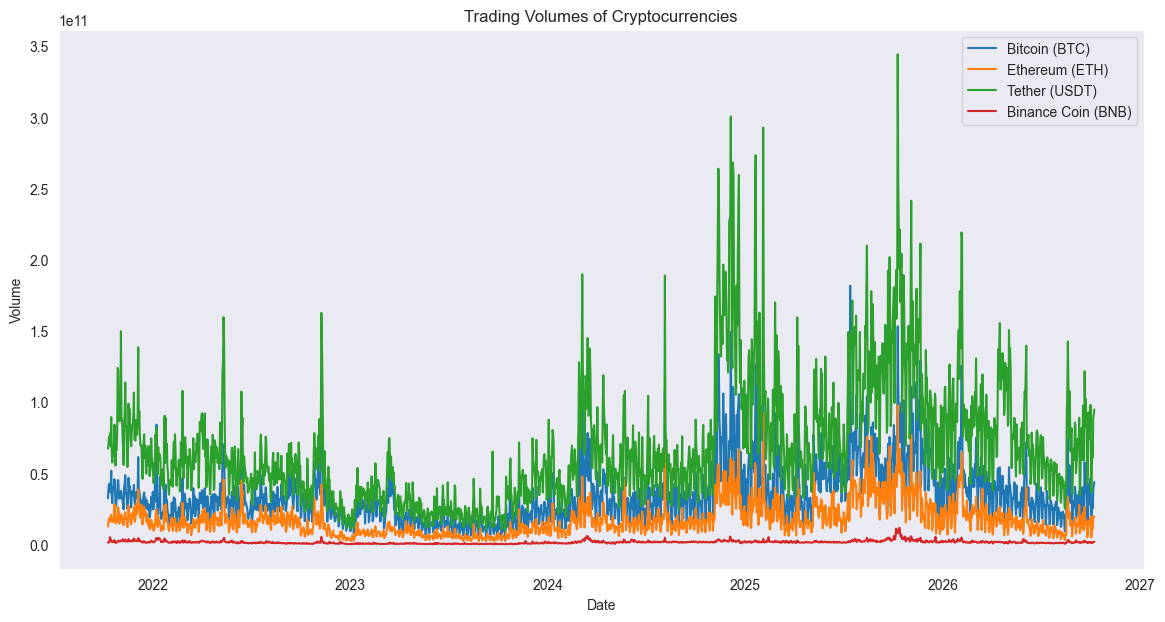

In [25]:
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Volume (BTC)'], label='Bitcoin (BTC)')
plt.plot(data.index, data['Volume (ETH)'], label='Ethereum (ETH)')
plt.plot(data.index, data['Volume (USDT)'], label='Tether (USDT)')
plt.plot(data.index, data['Volume (BNB)'], label='Binance Coin (BNB)')
plt.title('Trading Volumes of Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()

# Correlation Analysis

In [26]:
corr_matrix = data[['Close (BTC)', 'Close (ETH)', 'Close (USDT)', 'Close (BNB)']].corr()

# plot the heatmap

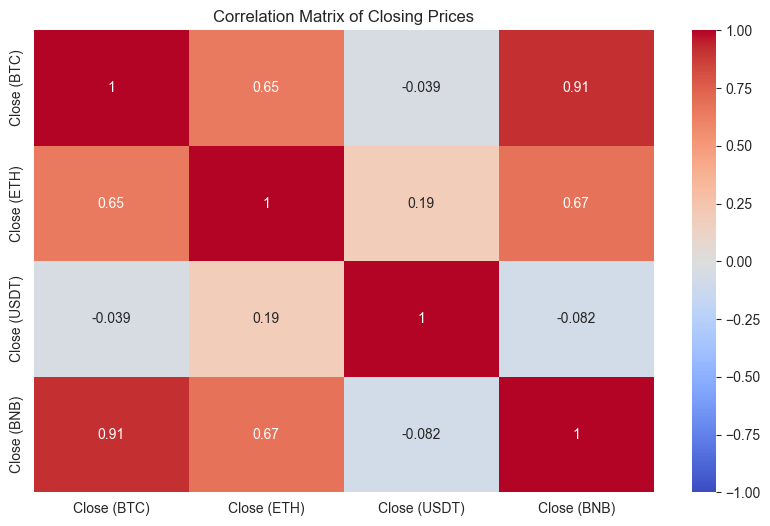

In [27]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Closing Prices')
plt.show()

# distribution of closing prices

Text(0.5, 1.0, 'Distribution of Bitcoin (BTC) Closing Prices')

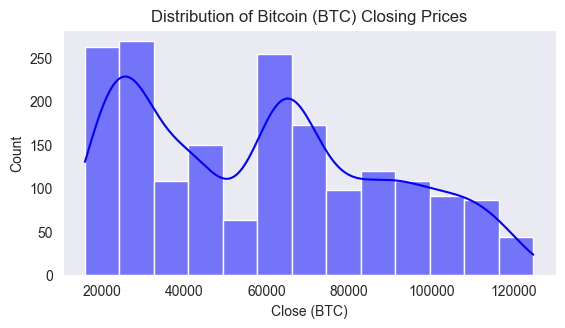

In [29]:
plt.figure(figsize=(14, 7))
plt.subplot(2, 2, 1)
sns.histplot(data['Close (BTC)'], kde=True, color='blue')
plt.title('Distribution of Bitcoin (BTC) Closing Prices')


Text(0.5, 1.0, 'Distribution of Ethereum (ETH) Closing Prices')

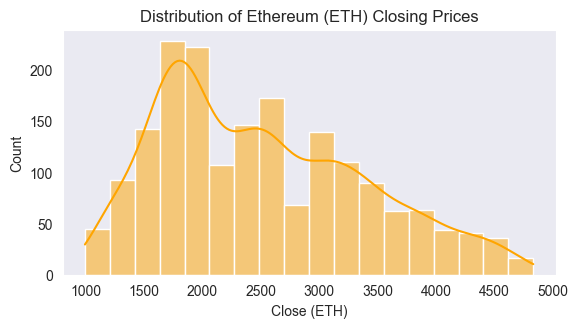

In [32]:
plt.figure(figsize=(14, 7))
plt.subplot(2, 2, 2)
sns.histplot(data['Close (ETH)'], kde=True, color='orange')
plt.title('Distribution of Ethereum (ETH) Closing Prices')

Text(0.5, 1.0, 'Distribution of Tether (USDT) Closing Prices')

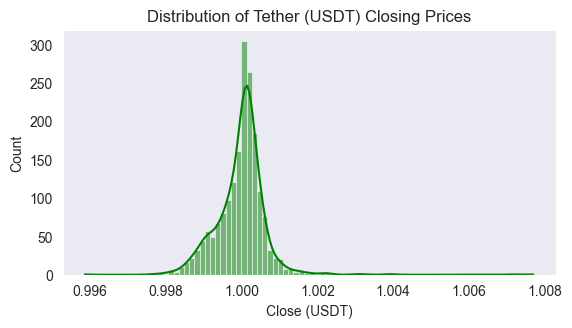

In [34]:
plt.figure(figsize=(14, 7))
plt.subplot(2, 2, 3)
sns.histplot(data['Close (USDT)'], kde=True, color='green')
plt.title('Distribution of Tether (USDT) Closing Prices')


Text(0.5, 1.0, 'Distribution of Binance Coin (BNB) Closing Prices')

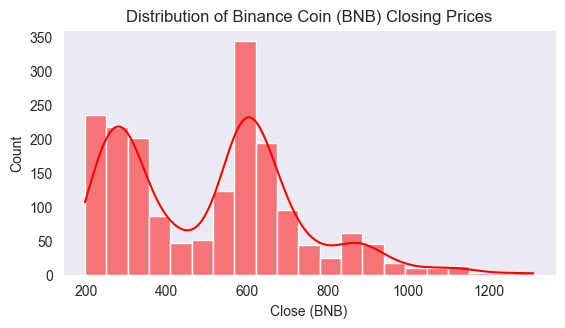

In [35]:
plt.figure(figsize=(14, 7))
plt.subplot(2, 2, 4)
sns.histplot(data['Close (BNB)'], kde=True, color='red')
plt.title('Distribution of Binance Coin (BNB) Closing Prices')


# Let's plot the distribution of closing prices for each cryptocurrency

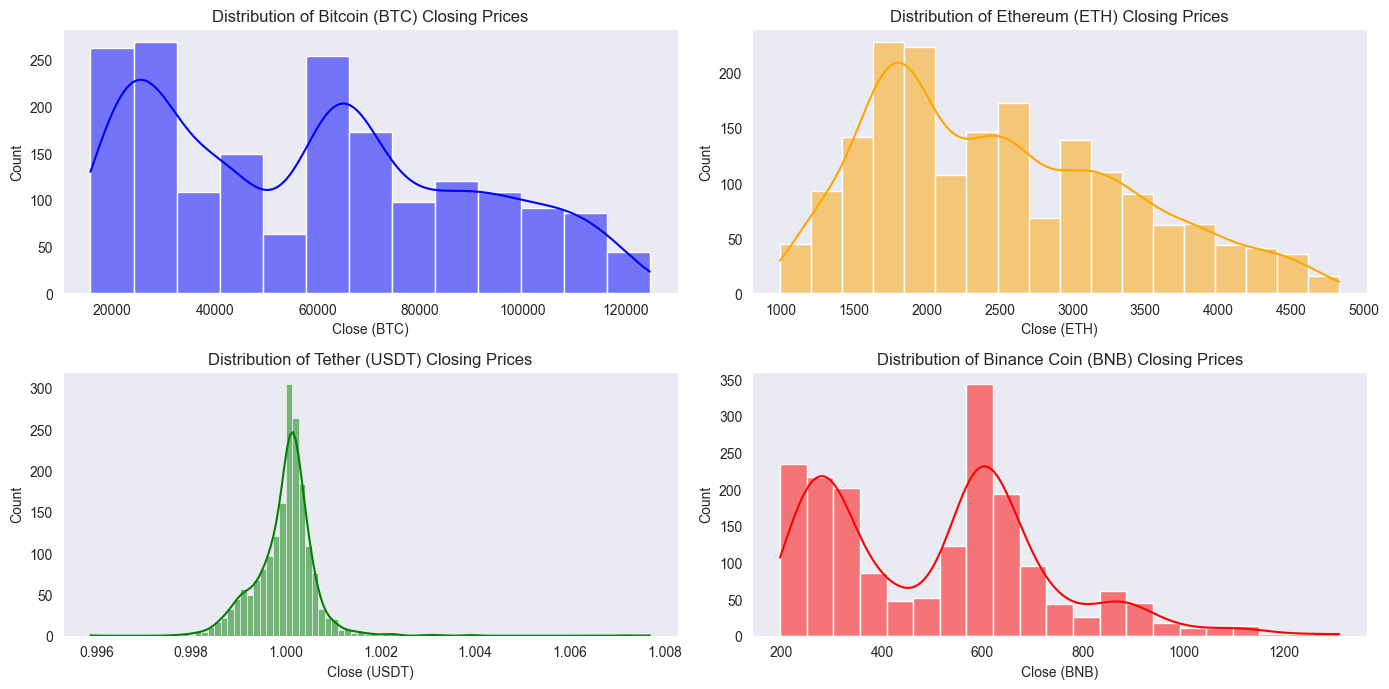

In [36]:
plt.figure(figsize=(14, 7))

plt.subplot(2, 2, 1)
sns.histplot(data['Close (BTC)'], kde=True, color='blue')
plt.title('Distribution of Bitcoin (BTC) Closing Prices')

plt.subplot(2, 2, 2)
sns.histplot(data['Close (ETH)'], kde=True, color='orange')
plt.title('Distribution of Ethereum (ETH) Closing Prices')

plt.subplot(2, 2, 3)
sns.histplot(data['Close (USDT)'], kde=True, color='green')
plt.title('Distribution of Tether (USDT) Closing Prices')

plt.subplot(2, 2, 4)
sns.histplot(data['Close (BNB)'], kde=True, color='red')
plt.title('Distribution of Binance Coin (BNB) Closing Prices')

plt.tight_layout()
plt.show()


array([[<Axes: title={'center': 'Close (BTC)'}>,
        <Axes: title={'center': 'Volume (BTC)'}>,
        <Axes: title={'center': 'Close (ETH)'}>,
        <Axes: title={'center': 'Volume (ETH)'}>],
       [<Axes: title={'center': 'Close (USDT)'}>,
        <Axes: title={'center': 'Volume (USDT)'}>,
        <Axes: title={'center': 'Close (BNB)'}>,
        <Axes: title={'center': 'Volume (BNB)'}>]], dtype=object)

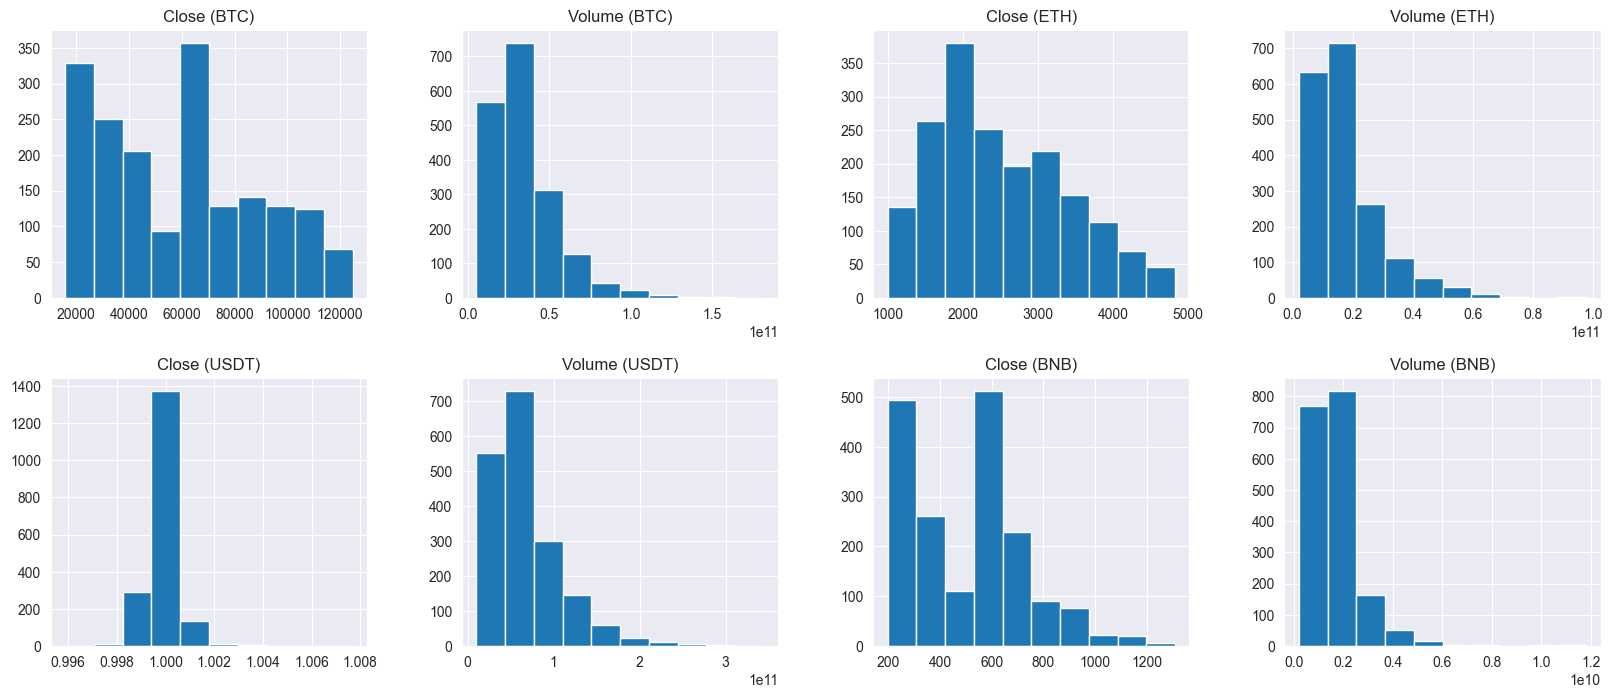

In [37]:
data.hist(figsize=(20, 8), layout=(2, 4))

# kde plot

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>]], dtype=object)

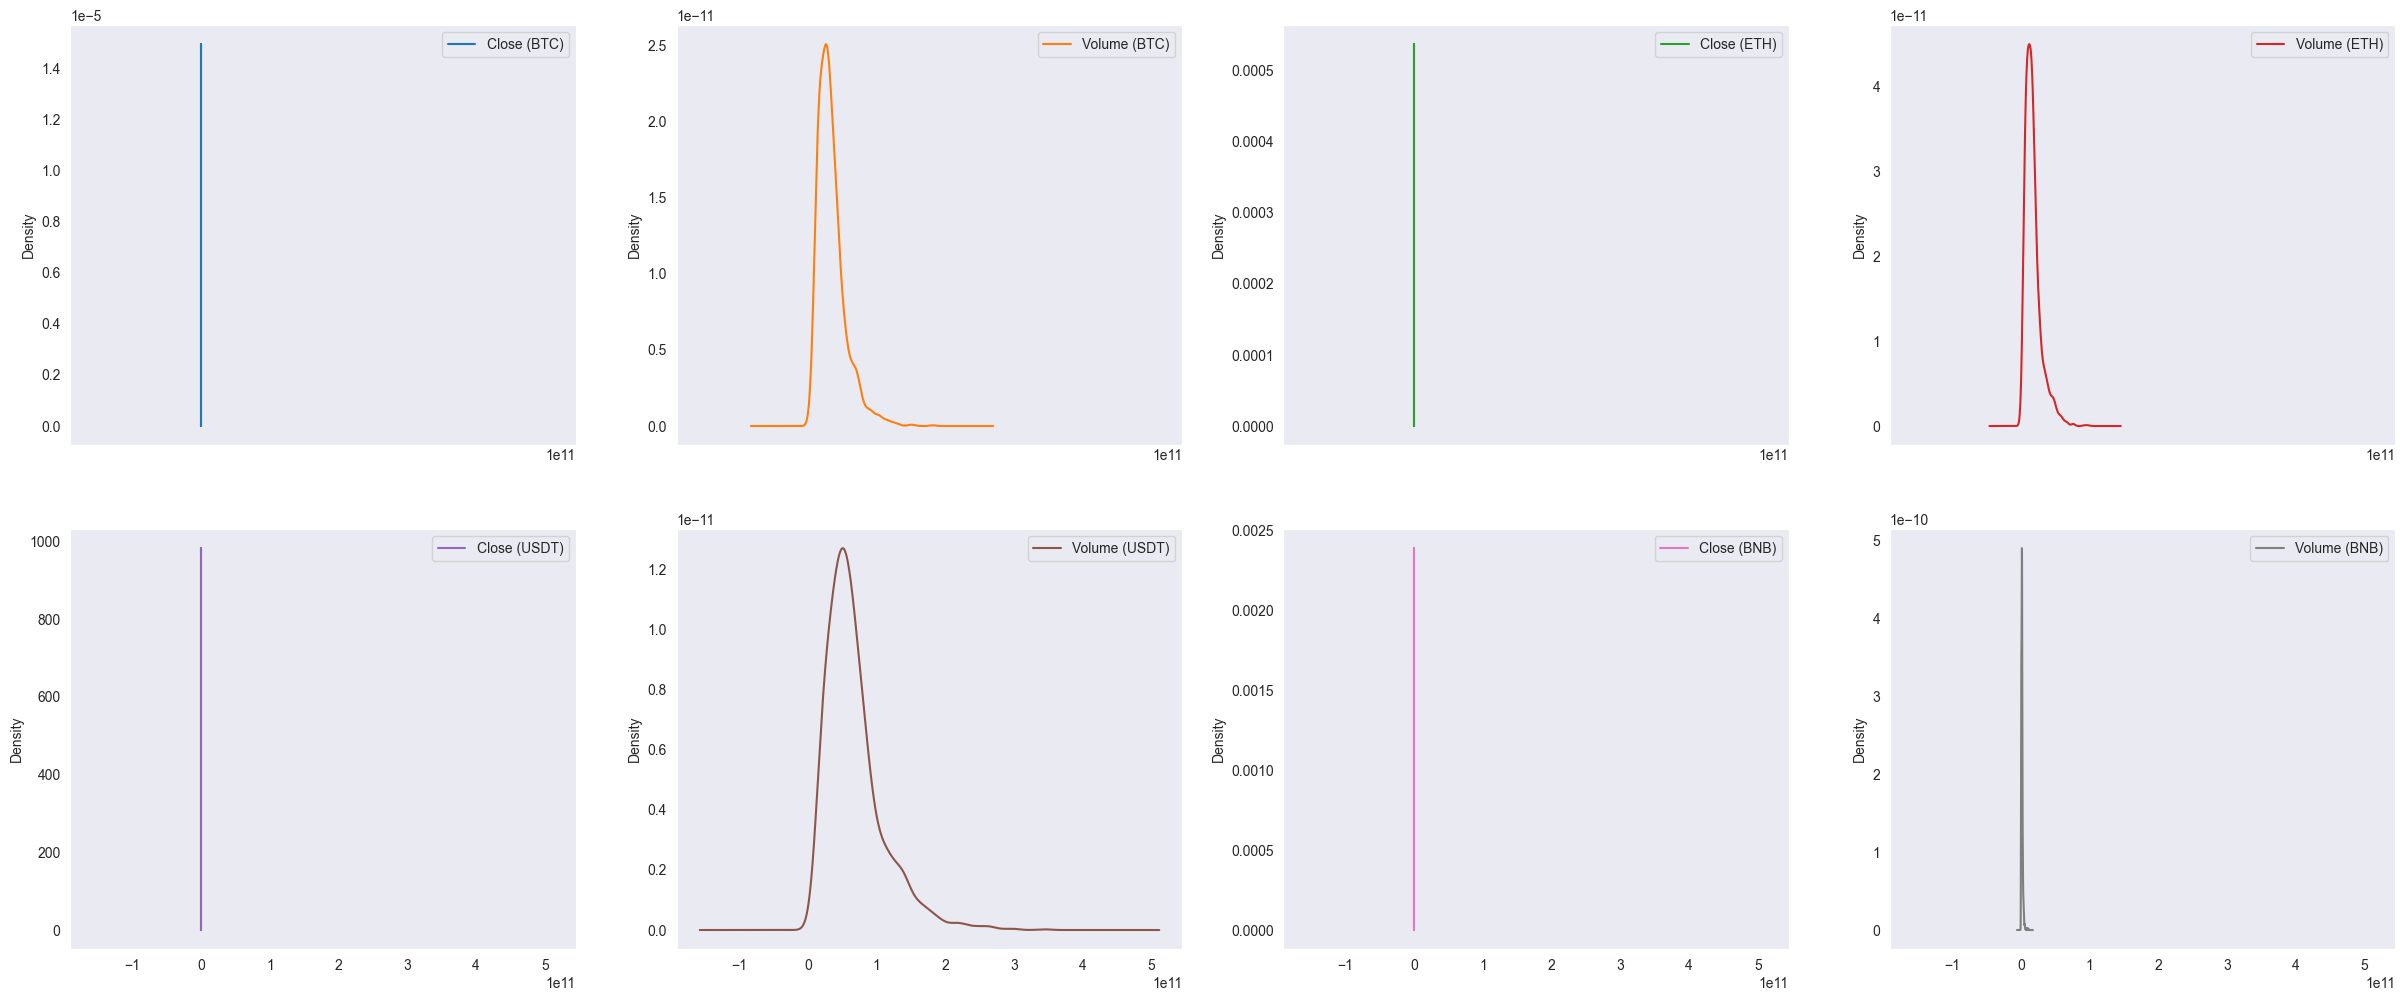

In [39]:
data.plot(kind = "kde", subplots = True, layout = (2, 4), figsize = (30, 12))

# pairplot

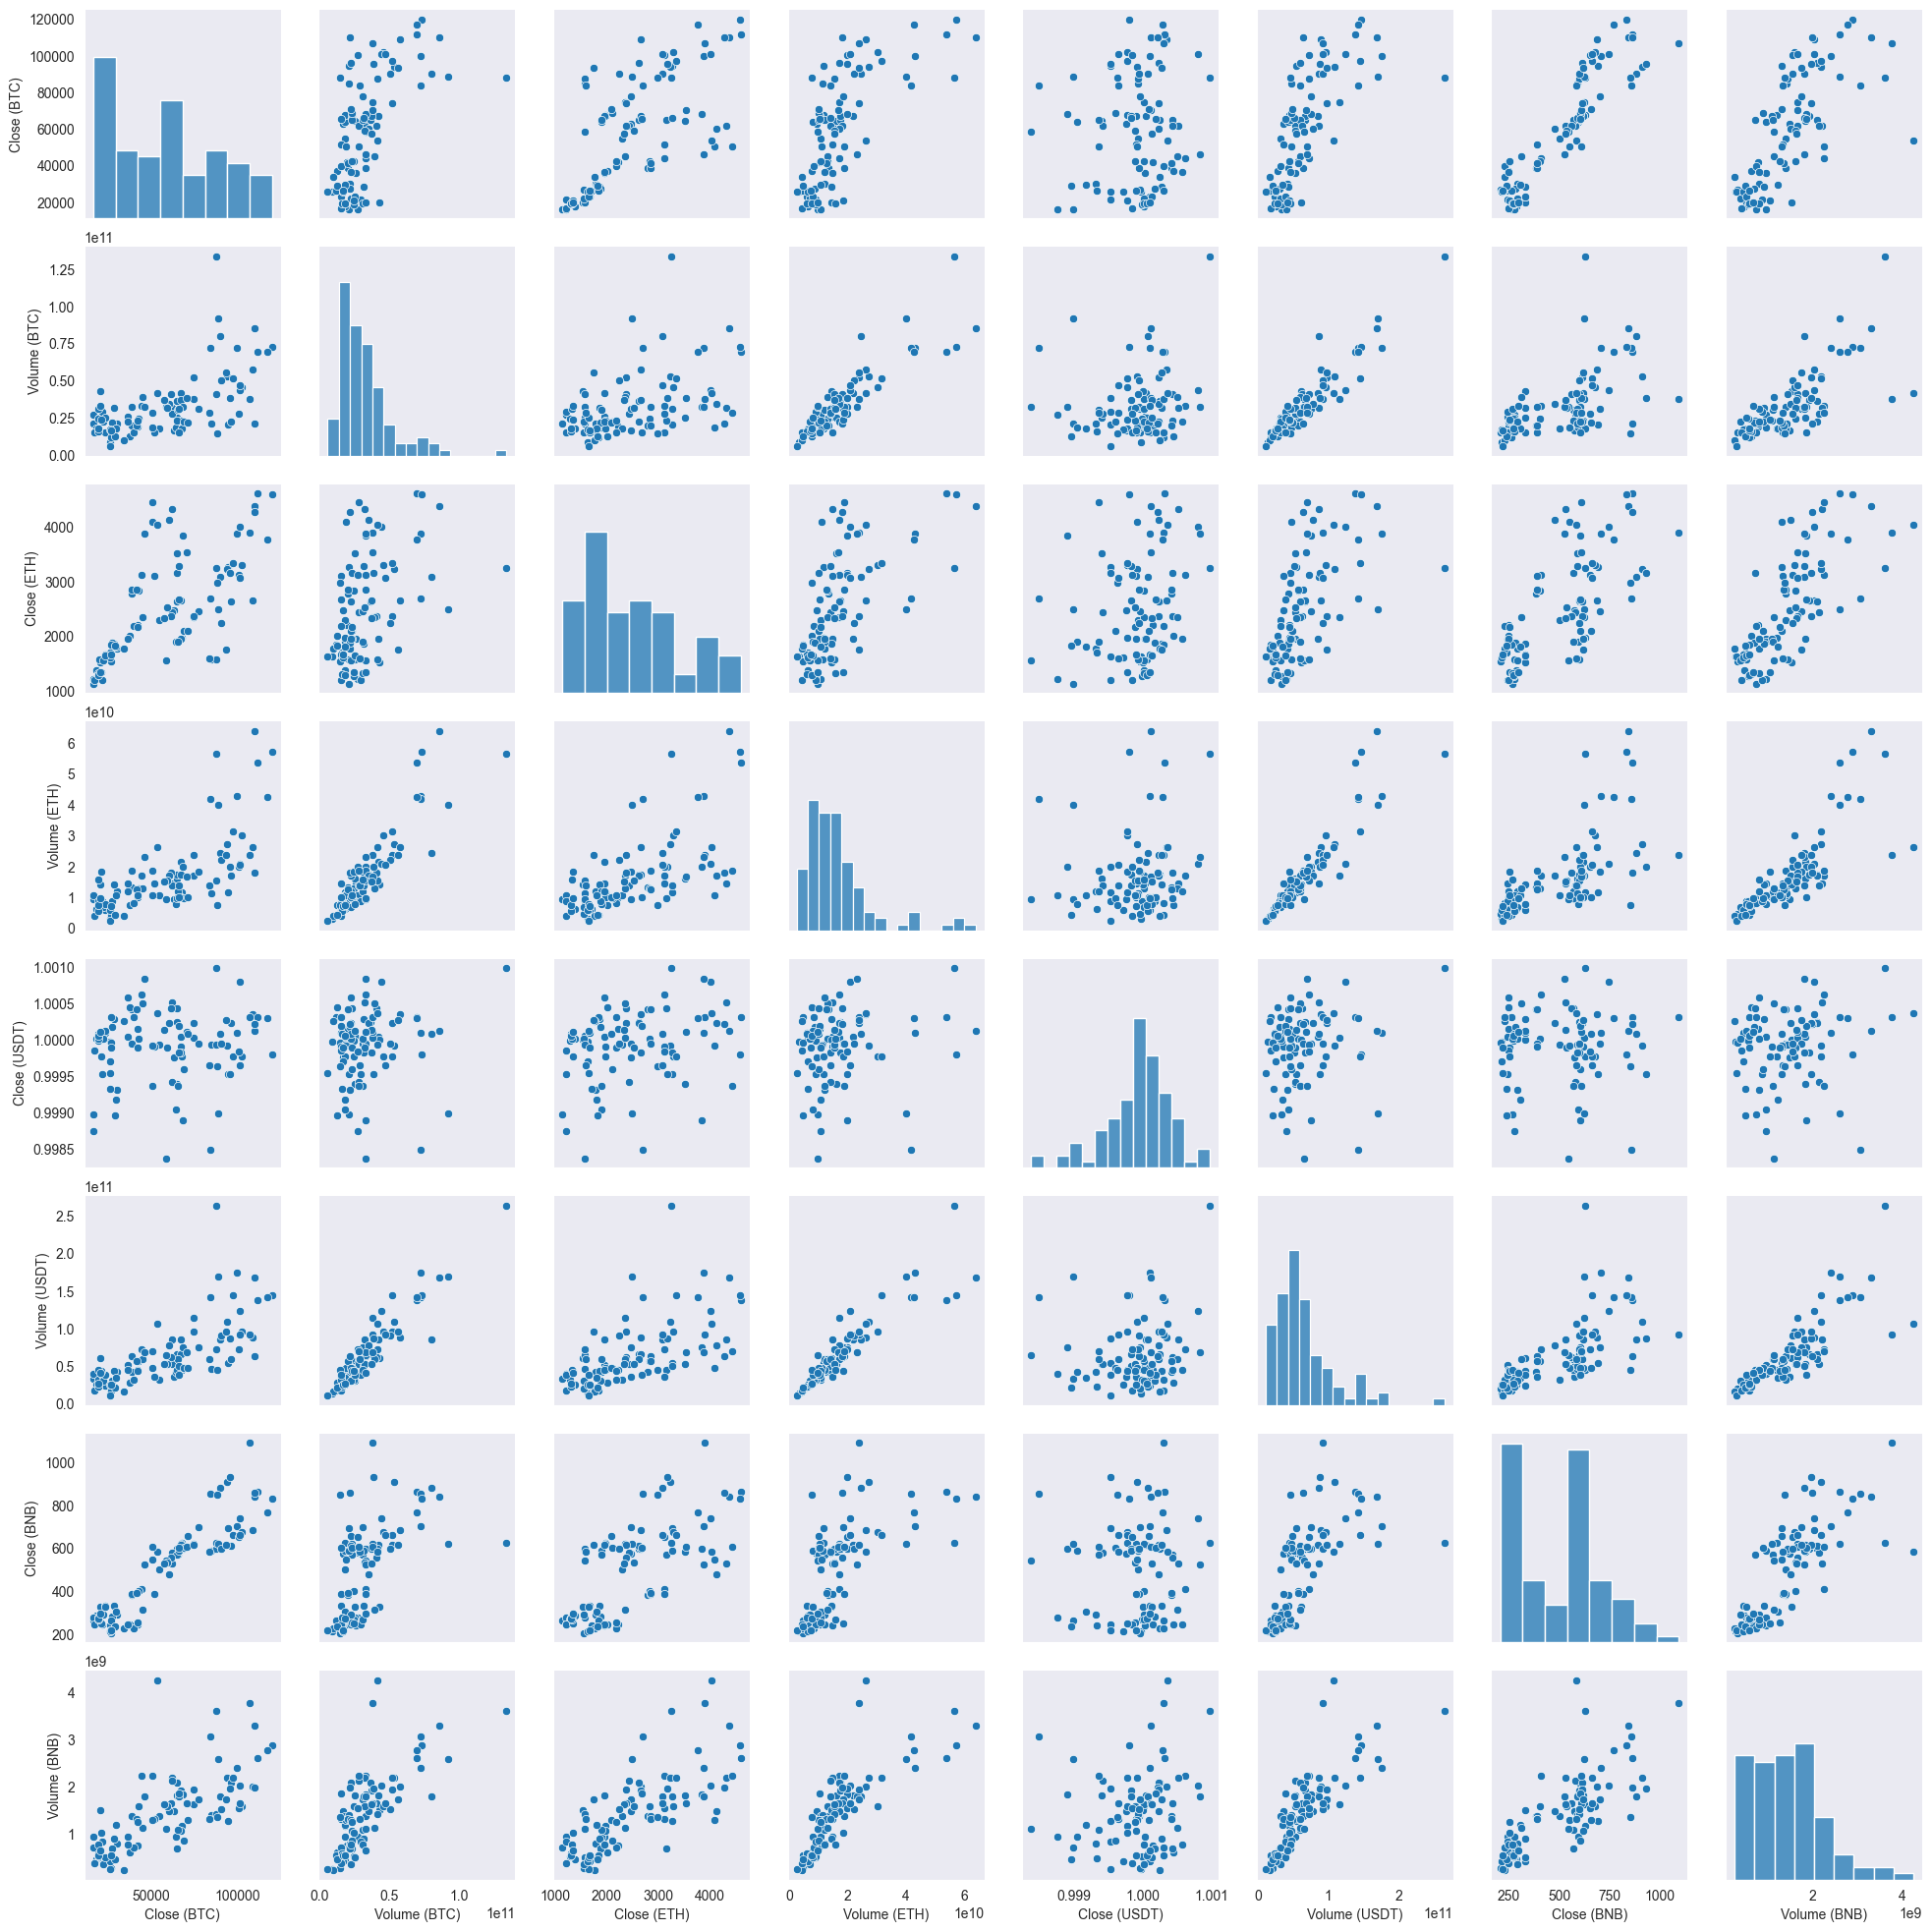

In [43]:
sns.pairplot(data.sample(n=100));

# data pre-processing

In [44]:
X = data.drop(columns = ['Close (BTC)'], axis = 1)
Y = data.loc[:, 'Close (BTC)']

In [45]:
X.head()

,Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,
2021-10-09 00:00:00+00:00,32491211414,3575.716797,12707036942,1.000046,67391135102,421.549469,1404867667
2021-10-10 00:00:00+00:00,39527792364,3425.852783,16171746693,1.001018,69927661418,405.069305,1437068558
2021-10-11 00:00:00+00:00,42637331698,3545.354004,18579189588,1.000696,75741431317,413.456207,1473121389
2021-10-12 00:00:00+00:00,41083758949,3492.573242,18109578443,1.000096,73275476508,443.867523,3142304145
2021-10-13 00:00:00+00:00,41684252783,3606.201660,16211275589,1.000097,78117249743,470.749695,5149146903


In [46]:
X.tail()

,Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,
2026-10-04 00:00:00+00:00,15031650242,2726.509033,5943841130,0.999790,38186771396,795.264099,1195825218
2026-10-05 00:00:00+00:00,30242651384,2711.031494,12303844539,0.999853,71514114557,786.810486,1629945521
2026-10-06 00:00:00+00:00,25245965925,2697.516357,10986122667,0.999845,60953147088,779.615967,1273219160
2026-10-07 00:00:00+00:00,38737709051,2573.527344,20082324906,0.999445,88736239765,772.301270,1545007708
2026-10-09 00:00:00+00:00,43922284544,2489.320068,19351347200,0.999200,94872002560,740.679993,1955062016


In [47]:
Y.head()

Date
2021-10-09 00:00:00+00:00    54968.222656
2021-10-10 00:00:00+00:00    54771.578125
2021-10-11 00:00:00+00:00    57484.789062
2021-10-12 00:00:00+00:00    56041.058594
2021-10-13 00:00:00+00:00    57401.097656
Name: Close (BTC), dtype: float64

In [48]:
Y.tail()

Date
2026-10-04 00:00:00+00:00    86480.304688
2026-10-05 00:00:00+00:00    85786.593750
2026-10-06 00:00:00+00:00    85557.562500
2026-10-07 00:00:00+00:00    83275.929688
2026-10-09 00:00:00+00:00    82292.570312
Name: Close (BTC), dtype: float64

# split training and testing

In [49]:

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [50]:
X_train

,Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,
2026-04-18 00:00:00+00:00,26014416776,2351.100586,14400085617,1.000287,108840158490,630.322449,1585391318
2025-08-30 00:00:00+00:00,51486264208,4374.153320,25883112278,1.000057,82307848032,862.403992,2030968355
2025-11-01 00:00:00+00:00,25871668762,3874.187988,17490279524,0.999664,74530426678,1094.642334,2138185589
2025-01-07 00:00:00+00:00,58685738547,3381.577393,32235312545,0.999924,131667426225,697.368896,2200352831
2023-12-10 00:00:00+00:00,13000481418,2352.462646,7369608905,1.000044,32521476893,239.733154,640133489
...,...,...,...,...,...,...,...
2024-01-22 00:00:00+00:00,31338708143,2310.826416,13923771728,0.998853,49537774963,305.437012,948987847
2025-02-06 00:00:00+00:00,45302471947,2688.400879,29500645692,1.000170,99009274148,572.274048,1722558011
2026-04-19 00:00:00+00:00,30931515195,2264.916992,17083701612,1.000198,109498515721,616.524475,1507732097


In [51]:
Y_test

Date
2023-12-11 00:00:00+00:00    41243.832031
2023-12-07 00:00:00+00:00    43292.664062
2022-02-04 00:00:00+00:00    41500.875000
2022-08-23 00:00:00+00:00    21528.087891
2024-03-18 00:00:00+00:00    67548.593750
                                 ...     
2022-10-20 00:00:00+00:00    19053.740234
2023-10-03 00:00:00+00:00    27429.978516
2026-06-05 00:00:00+00:00    60922.667969
2022-07-06 00:00:00+00:00    20548.246094
2022-05-24 00:00:00+00:00    29655.585938
Name: Close (BTC), Length: 366, dtype: float64

In [52]:
X_train

,Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,
2026-04-18 00:00:00+00:00,26014416776,2351.100586,14400085617,1.000287,108840158490,630.322449,1585391318
2025-08-30 00:00:00+00:00,51486264208,4374.153320,25883112278,1.000057,82307848032,862.403992,2030968355
2025-11-01 00:00:00+00:00,25871668762,3874.187988,17490279524,0.999664,74530426678,1094.642334,2138185589
2025-01-07 00:00:00+00:00,58685738547,3381.577393,32235312545,0.999924,131667426225,697.368896,2200352831
2023-12-10 00:00:00+00:00,13000481418,2352.462646,7369608905,1.000044,32521476893,239.733154,640133489
...,...,...,...,...,...,...,...
2024-01-22 00:00:00+00:00,31338708143,2310.826416,13923771728,0.998853,49537774963,305.437012,948987847
2025-02-06 00:00:00+00:00,45302471947,2688.400879,29500645692,1.000170,99009274148,572.274048,1722558011
2026-04-19 00:00:00+00:00,30931515195,2264.916992,17083701612,1.000198,109498515721,616.524475,1507732097


In [53]:
Y_train

Date
2026-04-18 00:00:00+00:00     75726.210938
2025-08-30 00:00:00+00:00    108808.070312
2025-11-01 00:00:00+00:00    110064.015625
2025-01-07 00:00:00+00:00     96922.703125
2023-12-10 00:00:00+00:00     43779.699219
                                 ...      
2024-01-22 00:00:00+00:00     39507.367188
2025-02-06 00:00:00+00:00     96593.296875
2026-04-19 00:00:00+00:00     73856.351562
2023-04-21 00:00:00+00:00     27276.910156
2023-08-24 00:00:00+00:00     26162.373047
Name: Close (BTC), Length: 1460, dtype: float64

In [54]:
X_train.shape

(1460, 7)

In [55]:
X_test.shape

(366, 7)

In [56]:
Y_test.shape

(366,)

In [57]:
Y_train.shape

(1460,)

# feature selecation--

# k value=4

In [58]:
from sklearn.feature_selection import SelectKBest

fs = SelectKBest(k=4)
X_train = fs.fit_transform(X_train, Y_train)
X_test = fs.transform(X_test)

C:\Users\SHUBHAM\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)


In [59]:
mask = fs.get_support()
selected_features = X.columns[mask]
print("Selected Features:", selected_features) 

Selected Features: Index(['Close (USDT)', 'Volume (USDT)', 'Close (BNB)', 'Volume (BNB)'], dtype='object')


In [60]:
X_train

array([[1.00028706e+00, 1.08840158e+11, 6.30322449e+02, 1.58539132e+09],
       [1.00005698e+00, 8.23078480e+10, 8.62403992e+02, 2.03096836e+09],
       [9.99664009e-01, 7.45304267e+10, 1.09464233e+03, 2.13818559e+09],
       ...,
       [1.00019801e+00, 1.09498516e+11, 6.16524475e+02, 1.50773210e+09],
       [1.00014198e+00, 3.45534960e+10, 3.21674988e+02, 1.05753080e+09],
       [9.99426007e-01, 2.00707361e+10, 2.18646393e+02, 3.94620698e+08]],
      shape=(1460, 4))

# min max scaler--

In [61]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# implementation of 10 different regression algorithm

In [62]:

from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [63]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'ElasticNet Regression': ElasticNet(alpha=1.0, l1_ratio=0.5),
    'Support Vector Regression (SVR)': SVR(kernel='rbf'),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest Regression': RandomForestRegressor(n_estimators=100),
    'Gradient Boosting Regression': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1),
    'K-Nearest Neighbors Regression': KNeighborsRegressor(n_neighbors=5),
    'Neural Network Regression (MLP)': MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam')
}

In [64]:
# Train and evaluate each model
results = {'Model': [], 'MSE': [], 'R-squared': []}

In [68]:
results = {'Model': [], 'MSE': [], 'R-squared': []}

for name, model in models.items():
    # Train the model
    model.fit(X_train, Y_train)

    # Predict on test set
    Y_pred = model.predict(X_test)

C:\Users\SHUBHAM\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [69]:
Y_pred

array([ 44039.94710305,  42199.8696466 ,  49471.15992599,  43662.67079676,
        60426.91595405,  61986.90992907,  43949.98224829,  47901.09186585,
        43053.41933791,  53210.3483828 ,  41623.91630711,  51050.24508944,
        73353.13874389,  50419.7385603 ,  51578.21797747,  60750.93855137,
        37468.16756518,  47436.71795169,  51170.73024763,  59147.82517857,
        42343.14119443,  46367.1837328 ,  35480.66043768,  40723.68556751,
        39812.99462774,  51555.32987733,  37590.17314752,  47076.28265088,
        51461.86841885,  67288.88537147,  59548.95086076,  59369.59407581,
        43015.09553507,  94829.6011543 ,  40646.56075913,  41204.52779718,
        51358.27743416,  55585.57973393,  75006.29419835,  54168.97774842,
        65712.05532796,  58089.58879199,  52922.02370342,  56478.23804799,
        75787.47121599,  48507.53674839,  40995.32850204,  70011.75748512,
        56898.02133281,  57901.03617424,  75088.74066686,  68274.60393495,
        52298.45900194,  

In [70]:
Y_pred.shape

(366,)

In [72]:
  # Evaluate model
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

In [73]:
mse

529091389.5162027

In [74]:
r2

0.3986972589072836

In [76]:
   # Store results
results['Model'].append(name)
results['MSE'].append(mse)
results['R-squared'].append(r2)


In [77]:
results

{'Model': ['Neural Network Regression (MLP)'],
 'MSE': [529091389.5162027],
 'R-squared': [0.3986972589072836]}

In [78]:
 # Print results
print(f"----- {name} -----")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared: {r2}")
print()

----- Neural Network Regression (MLP) -----
Mean Squared Error (MSE): 529091389.5162027
R-squared: 0.3986972589072836



# convert the dataframe

In [79]:
results_df = pd.DataFrame(results)
print(results_df)


                             Model           MSE  R-squared
0  Neural Network Regression (MLP)  5.290914e+08   0.398697


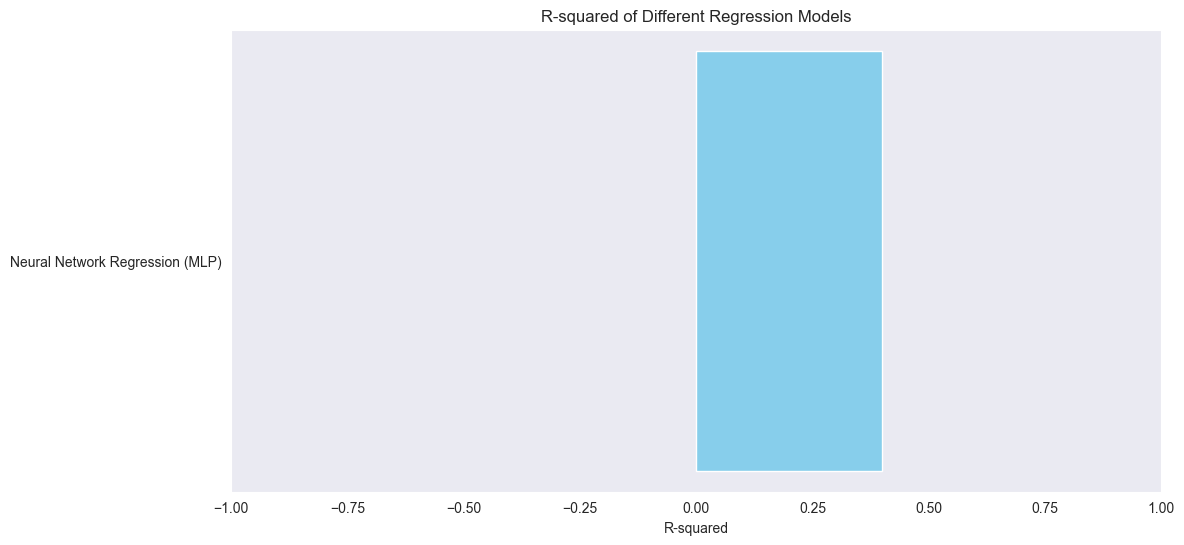

In [80]:
# Plotting the results
plt.figure(figsize=(12, 6))
plt.barh(results_df['Model'], results_df['R-squared'], color='skyblue')
plt.xlabel('R-squared')
plt.title('R-squared of Different Regression Models')
plt.xlim(-1, 1)
plt.gca().invert_yaxis()
plt.show()


----- Linear Regression -----
Mean Squared Error (MSE): 127203850.878152
R-squared: 0.8554351370553922

----- Ridge Regression -----
Mean Squared Error (MSE): 128562095.265792
R-squared: 0.8538915170125325

----- Lasso Regression -----
Mean Squared Error (MSE): 127164229.55777541
R-squared: 0.8554801659653692

----- ElasticNet Regression -----
Mean Squared Error (MSE): 750823986.9039713
R-squared: 0.14670219483945302

----- Support Vector Regression (SVR) -----
Mean Squared Error (MSE): 869203852.3112106
R-squared: 0.012165630892252532

----- Decision Tree Regression -----
Mean Squared Error (MSE): 108906973.28202829
R-squared: 0.8762292056605291

----- Random Forest Regression -----
Mean Squared Error (MSE): 65671354.17415365
R-squared: 0.9253657004089652

----- Gradient Boosting Regression -----
Mean Squared Error (MSE): 63223127.44179014
R-squared: 0.9281480655620491

----- K-Nearest Neighbors Regression -----
Mean Squared Error (MSE): 69091790.7175319
R-squared: 0.9214784364881751


C:\Users\SHUBHAM\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


----- Neural Network Regression (MLP) -----
Mean Squared Error (MSE): 1030691482.9036891
R-squared: -0.17136212414571106

                             Model           MSE  R-squared
0                Linear Regression  1.272039e+08   0.855435
1                 Ridge Regression  1.285621e+08   0.853892
2                 Lasso Regression  1.271642e+08   0.855480
3            ElasticNet Regression  7.508240e+08   0.146702
4  Support Vector Regression (SVR)  8.692039e+08   0.012166
5         Decision Tree Regression  1.089070e+08   0.876229
6         Random Forest Regression  6.567135e+07   0.925366
7     Gradient Boosting Regression  6.322313e+07   0.928148
8   K-Nearest Neighbors Regression  6.909179e+07   0.921478
9  Neural Network Regression (MLP)  1.030691e+09  -0.171362


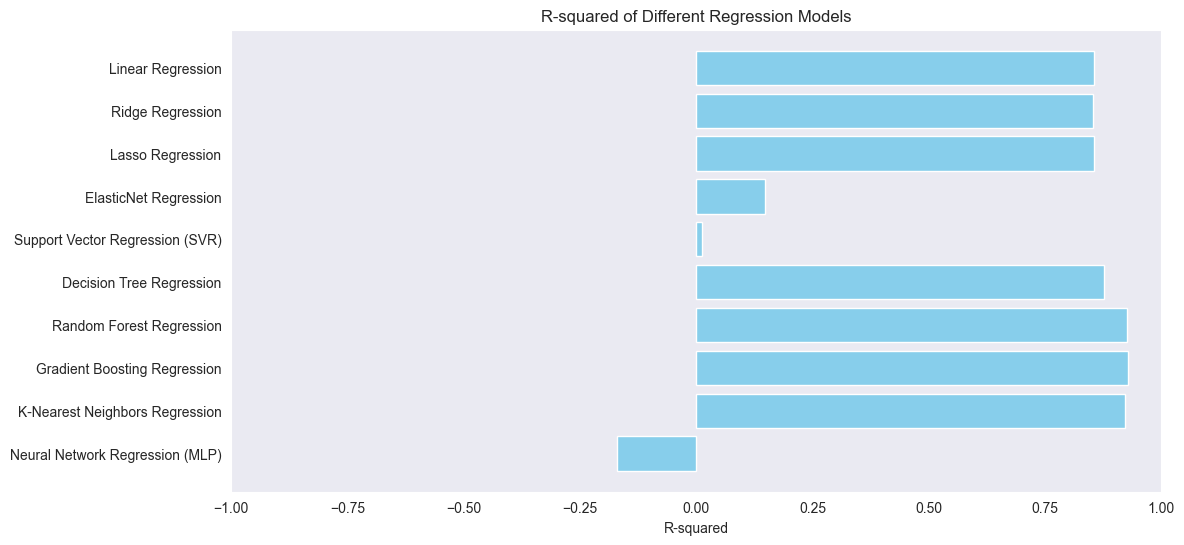

In [81]:

#Define Models and Perform Training and Evaluation
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'ElasticNet Regression': ElasticNet(alpha=1.0, l1_ratio=0.5),
    'Support Vector Regression (SVR)': SVR(kernel='rbf'),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest Regression': RandomForestRegressor(n_estimators=100),
    'Gradient Boosting Regression': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1),
    'K-Nearest Neighbors Regression': KNeighborsRegressor(n_neighbors=5),
    'Neural Network Regression (MLP)': MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam')
}

# Train and evaluate each model
results = {'Model': [], 'MSE': [], 'R-squared': []}

for name, model in models.items():
    # Train the model
    model.fit(X_train, Y_train)

    # Predict on test set
    Y_pred = model.predict(X_test)

    # Evaluate model
    mse = mean_squared_error(Y_test, Y_pred)
    r2 = r2_score(Y_test, Y_pred)

    # Store results
    results['Model'].append(name)
    results['MSE'].append(mse)
    results['R-squared'].append(r2)

    # Print results
    print(f"----- {name} -----")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"R-squared: {r2}")
    print()

# Convert results to DataFrame for visualization
results_df = pd.DataFrame(results)
print(results_df)

# Plotting the results
plt.figure(figsize=(12, 6))
plt.barh(results_df['Model'], results_df['R-squared'], color='skyblue')
plt.xlabel('R-squared')
plt.title('R-squared of Different Regression Models')
plt.xlim(-1, 1)
plt.gca().invert_yaxis()
plt.show()


# save the model

In [83]:
import pickle
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

# Generate sample data
X, Y = make_regression(n_samples=1000, n_features=10, noise=0.1, random_state=0)


# Scale the features (optional but recommended for some algorithms)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize Random Forest Regressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=0)

# Train the model
model_rf.fit(X_train, Y_train)

# Save the model to a file
filename = 'random_forest_model.pkl'
pickle.dump(model_rf, open(filename, 'wb'))

# Save scaler to a file
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Load the model from the file
loaded_model = pickle.load(open(filename, 'rb'))

# Predict using the loaded model
Y_pred = loaded_model.predict(X_test)

# Evaluate the loaded model
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Loaded Random Forest Regression - Mean Squared Error (MSE): {mse}")
print(f"Loaded Random Forest Regression - R-squared: {r2}")



Loaded Random Forest Regression - Mean Squared Error (MSE): 65182602.0365807
Loaded Random Forest Regression - R-squared: 0.925921158323913


In [84]:
import os

filename = "random_forest_model.pkl"

print("Current Working Directory:", os.getcwd())
print("Pickle File Location:", os.path.abspath(filename))
print("File Exists:", os.path.exists(filename))

Current Working Directory: C:\Users\SHUBHAM
Pickle File Location: C:\Users\SHUBHAM\random_forest_model.pkl
File Exists: True
